# DT00 — Chạy không tải drivetrain

Phân tích 4 run raw đã ghi ngày 19/07/2026. Đây là dữ liệu `dt00-v1` cũ: dùng để đọc tình trạng hiện tại, không dùng để xác nhận schema `fgc-ts-v1` mới.

## Câu hỏi

Ở cùng lệnh không tải, hai bên có đạt RPM tương đương không; dòng, độ rung và coast có dấu hiệu bất thường nào không?

In [1]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))

from analysis.notebook import load_test_data, setup_notebook, show_full_data

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

root = setup_notebook()
data = load_test_data(root, 'DT00')
pd.set_option('display.max_columns', 100)

In [2]:
display(Markdown('> **Lưu ý:** file hiện có là `dt00-v1`; cột `phase` chỉ được dùng để đọc dữ liệu cũ, không phải một phần của schema mới.'))
drive = data[data.phase.str.startswith('DRIVE_', na=False)].copy()
drive['direction'] = drive.phase.str.removeprefix('DRIVE_')
metrics = ['left_rpm', 'right_rpm', 'rpm_difference', 'left_current_a', 'right_current_a', 'angular_vibration_rms_deg_s']
summary = drive.groupby('direction')[metrics].mean().T.rename(columns={'FORWARD': 'Tiến', 'REVERSE': 'Lùi'}).round(2)
display(Markdown('## Số liệu drive trung bình của 4 run'))
display(summary)

> **Lưu ý:** file hiện có là `dt00-v1`; cột `phase` chỉ được dùng để đọc dữ liệu cũ, không phải một phần của schema mới.

## Số liệu drive trung bình của 4 run

direction,Tiến,Lùi
left_rpm,180.66,-179.38
right_rpm,181.78,-181.18
rpm_difference,5.05,6.29
left_current_a,0.87,0.82
right_current_a,0.67,0.70
angular_vibration_rms_deg_s,3.95,2.99


## RPM theo thời gian

Đường nét đứt là RPM mục tiêu. Mỗi ô là một run, để thấy rõ cả transient lẫn độ lặp lại.

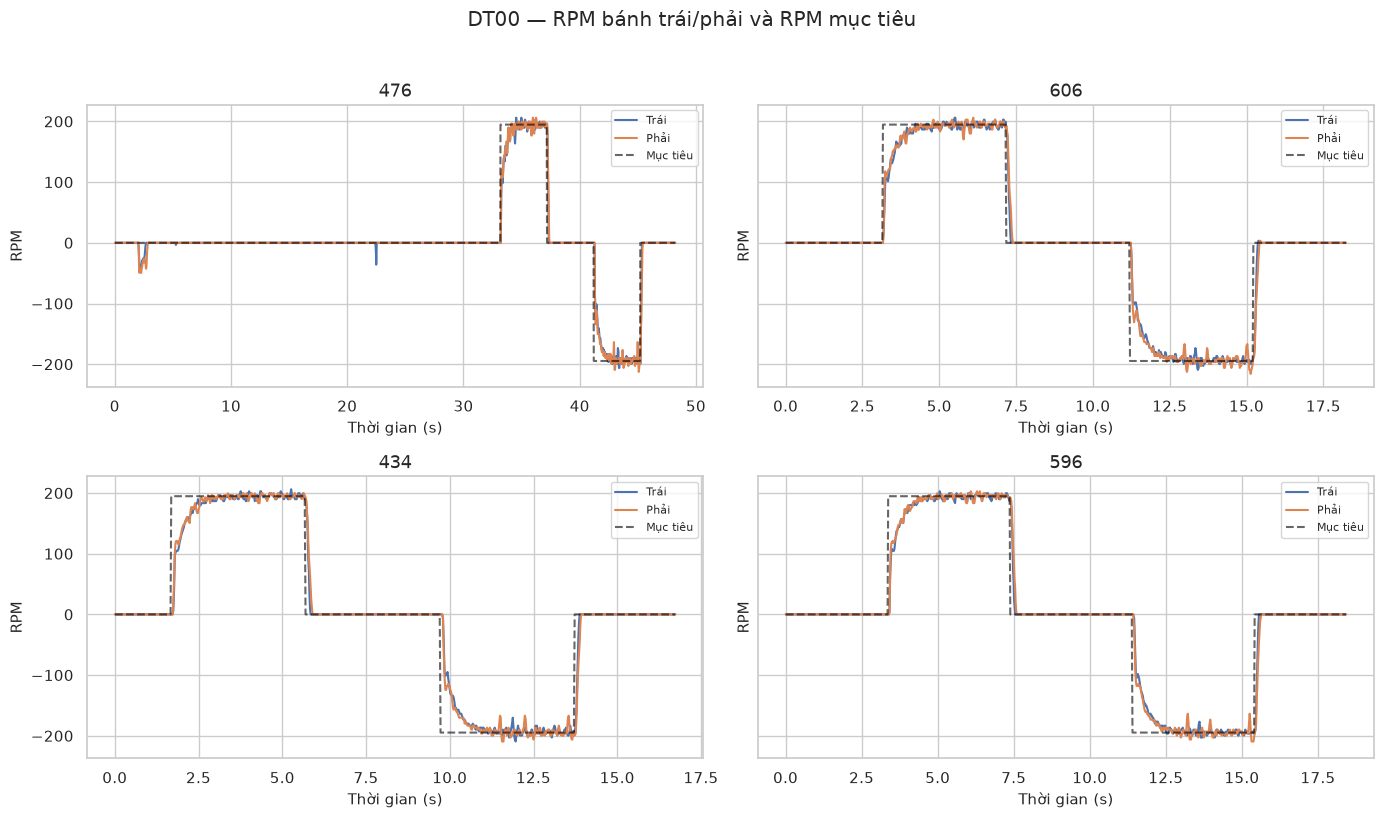

In [3]:
runs = list(data.groupby('run_id', sort=False))
figure, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for axis, (run_id, run) in zip(axes.flat, runs):
    axis.plot(run.time_s, run.left_rpm, label='Trái')
    axis.plot(run.time_s, run.right_rpm, label='Phải')
    axis.plot(run.time_s, run.target_rpm, '--', color='black', alpha=.6, label='Mục tiêu')
    axis.set(title=run_id.rsplit('_', 1)[-1], xlabel='Thời gian (s)', ylabel='RPM')
    axis.legend(fontsize=8)
figure.suptitle('DT00 — RPM bánh trái/phải và RPM mục tiêu', y=1.02)
figure.tight_layout()

## Dòng motor và điện áp

Đồ thị này tách vấn đề cơ khí khỏi thay đổi điện áp pin: dòng trái/phải được đọc cùng điện áp của run.

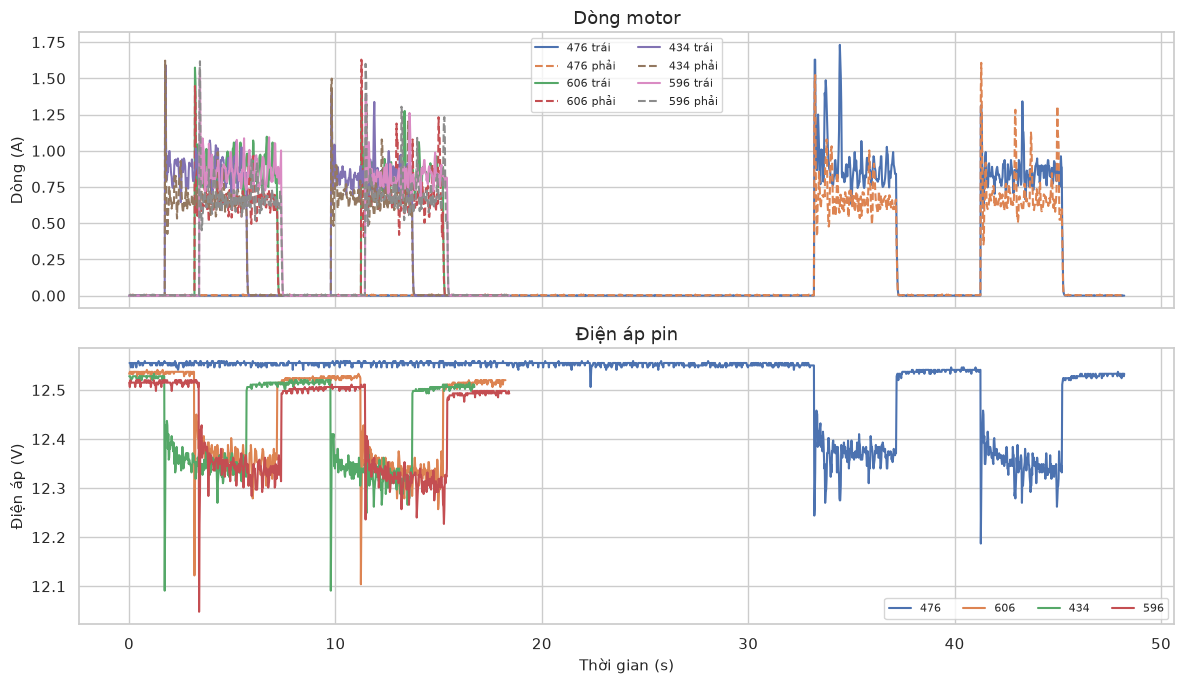

In [4]:
figure, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for run_id, run in data.groupby('run_id', sort=False):
    label = run_id.rsplit('_', 1)[-1]
    axes[0].plot(run.time_s, run.left_current_a, label=f'{label} trái')
    axes[0].plot(run.time_s, run.right_current_a, '--', label=f'{label} phải')
    axes[1].plot(run.time_s, run.battery_v, label=label)
axes[0].set(title='Dòng motor', ylabel='Dòng (A)'); axes[0].legend(ncol=2, fontsize=8)
axes[1].set(title='Điện áp pin', xlabel='Thời gian (s)', ylabel='Điện áp (V)'); axes[1].legend(ncol=4, fontsize=8)
figure.tight_layout()

## So sánh giữa các run

Mỗi chấm là trung bình của một run trong đoạn DRIVE. Cách nhìn này tránh để các run có nhiều mẫu hơn chi phối kết luận.

,run_id,direction,rpm_difference,angular_vibration_rms_deg_s
0,DT00_no_load_20260719_184224_476,FORWARD,5.72,6.88
1,DT00_no_load_20260719_184224_476,REVERSE,6.40,2.74
2,DT00_no_load_20260719_184410_606,FORWARD,5.47,4.26
3,DT00_no_load_20260719_184410_606,REVERSE,6.44,3.54
4,DT00_no_load_20260719_184519_434,FORWARD,4.76,2.16
5,DT00_no_load_20260719_184519_434,REVERSE,6.00,3.13
6,DT00_no_load_20260719_184630_596,FORWARD,4.25,2.55
7,DT00_no_load_20260719_184630_596,REVERSE,6.31,2.54


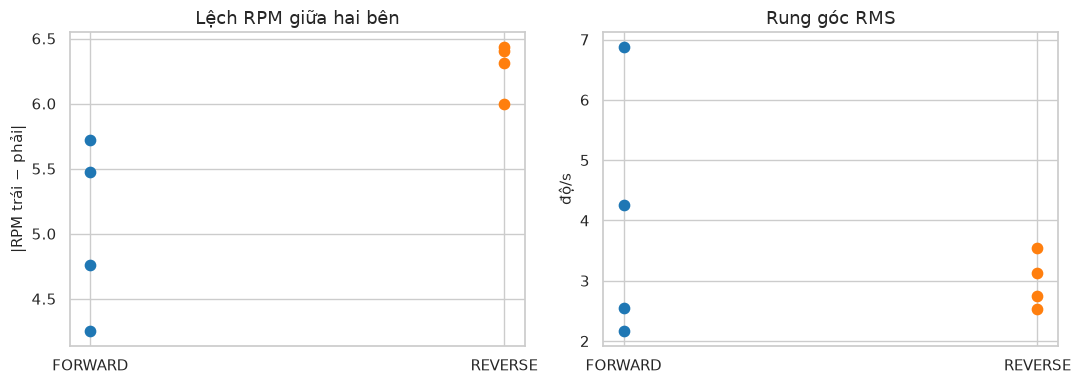

In [5]:
per_run = drive.groupby(['run_id', 'direction'])[['rpm_difference', 'angular_vibration_rms_deg_s']].mean().reset_index()
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for direction, color in [('FORWARD', 'tab:blue'), ('REVERSE', 'tab:orange')]:
    values = per_run[per_run.direction.eq(direction)]
    axes[0].scatter([direction] * len(values), values.rpm_difference, color=color, s=55)
    axes[1].scatter([direction] * len(values), values.angular_vibration_rms_deg_s, color=color, s=55)
axes[0].set(title='Lệch RPM giữa hai bên', ylabel='|RPM trái − phải|')
axes[1].set(title='Rung góc RMS', ylabel='độ/s')
figure.tight_layout()
display(per_run.round(2))

## Nhận xét từ dữ liệu hiện có

- Khi đã vào DRIVE, RPM trung bình hai bên gần nhau: lệch khoảng 5.05 RPM khi tiến và 6.29 RPM khi lùi. Trong các mẫu đã `settled`, lệch còn khoảng 4 RPM.
- Dòng bên trái cao hơn bên phải khoảng 0.20 A khi tiến và 0.12 A khi lùi. Mức này chưa tự nó kết luận lỗi, nhưng nên theo dõi cùng kiểm tra cơ khí.
- Rung góc trung bình khi tiến cao hơn lùi (khoảng 3.95 so với 2.99 độ/s). Một số đỉnh khi tiến lên 17.77 độ/s, nên lặp lại thêm run và quan sát bánh/hộp số bên trái trước khi chỉnh control.
- Điện áp nằm trong khoảng 12.187–12.559 V. Run đầu có hơn 32 giây WAITING; các biểu đồ giữ nguyên timeline để thấy điều đó, còn số liệu tóm tắt chỉ tính DRIVE.
- Lần ghi tiếp theo cần dùng `ExperimentLogger`: event chuẩn `LOG_START`, `START`, `COMMAND_START`, `TARGET_REACHED`, `COMMAND_STOP`, `STOPPED`, `END`; không mang `phase` sang schema mới.

## Dữ liệu đầy đủ

Bảng dưới giữ nguyên toàn bộ cột và mẫu đã nạp từ CSV.

In [6]:
show_full_data(data)

## Dữ liệu đầy đủ

,schema_version,run_id,scenario_id,sample,time_s,loop_dt_ms,phase,event,command,target_tps,target_rpm,left_actual_tps,right_actual_tps,left_rpm,right_rpm,left_current_a,right_current_a,rpm_difference,current_difference_a,left_position_ticks,right_position_ticks,battery_v,angular_x_deg_s,angular_y_deg_s,angular_z_deg_s,angular_vibration_rms_deg_s,left_rpm_ripple_rms,right_rpm_ripple_rms,rms_window_samples,settled,gear_reduction,wheel_diameter_mm,track_width_mm,standard_command,source_file
0,dt00-v1,DT00_no_load_20260719_184224_476,DT00,0,0.022772,22.772460,WAITING,RUN_START,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,0,0,12.555,0.000000e+00,0.000000e+00,0.08415,0.000000,0.000000,0.000000e+00,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184224_476.csv
1,dt00-v1,DT00_no_load_20260719_184224_476,DT00,1,0.054976,32.203795,WAITING,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,0,0,12.555,-1.862645e-08,8.415029e-02,-0.08415,0.094083,0.000000,0.000000e+00,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184224_476.csv
2,dt00-v1,DT00_no_load_20260719_184224_476,DT00,2,0.089343,34.366795,WAITING,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,0,0,12.546,-8.415025e-02,-1.683006e-01,0.00000,0.131567,0.000000,0.000000e+00,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184224_476.csv
3,dt00-v1,DT00_no_load_20260719_184224_476,DT00,3,0.126430,37.086879,WAITING,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,0,0,12.555,-8.415024e-02,-2.524509e-01,0.00000,0.151704,0.000000,0.000000e+00,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184224_476.csv
4,dt00-v1,DT00_no_load_20260719_184224_476,DT00,4,0.155865,29.435003,WAITING,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,0,0,12.555,1.862645e-08,-8.415029e-02,0.00000,0.136728,0.000000,0.000000e+00,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184224_476.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4806,dt00-v1,DT00_no_load_20260719_184630_596,DT00,884,18.355647,16.646877,COAST_REVERSE,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.000,0.0,0.000,55,-40,12.493,-4.470348e-08,2.524509e-01,0.00000,0.177284,0.000001,4.003729e-07,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184630_596.csv
4807,dt00-v1,DT00_no_load_20260719_184630_596,DT00,885,18.372230,16.583293,COAST_REVERSE,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,55,-40,12.493,0.000000e+00,0.000000e+00,0.00000,0.175872,0.000001,4.003729e-07,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184630_596.csv
4808,dt00-v1,DT00_no_load_20260719_184630_596,DT00,886,18.388412,16.181668,COAST_REVERSE,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.003,0.0,0.003,55,-40,12.498,-8.415029e-02,-1.862645e-08,0.08415,0.174449,0.000001,4.003729e-07,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184630_596.csv
4809,dt00-v1,DT00_no_load_20260719_184630_596,DT00,887,18.404595,16.183419,COAST_REVERSE,NaN,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.007,0.0,0.007,55,-40,12.493,1.862645e-08,-8.415029e-02,0.08415,0.170175,0.000001,4.003729e-07,25,False,13.0975,90.0,423.0,0.5,DT00_no_load_20260719_184630_596.csv
